# 04 — Pemodelan & Forecasting (Fase 3)

Prediksi harga H+7 dengan 3 model: **Moving Average**, **Exponential Smoothing (Holt)**, **ARIMA**.

> Data: `output/data_bersih_22.csv` (22 komoditas × 31 hari).
> K6 & K8 = data dummy → dikecualikan dari evaluasi.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")

BASE   = Path(r"C:\Users\LENOVO\Documents\TOOUUGUAASS\SMT 5\BRIDA PROJECTS")
NOTE   = BASE / "notebooks"
OUTPUT = NOTE / "output"
OUTPUT.mkdir(exist_ok=True)
FILE_BERSIH = OUTPUT / "data_bersih_22.csv"

KOMODITAS_DUMMY = ["K6", "K8"]   # dikecualikan dari evaluasi
print("File bersih ada:", FILE_BERSIH.exists())

File bersih ada: True


## Bab 1 — Load & siapkan seri

Satu seri = satu komoditas, index = tanggal, kolom = `harga_rata`.

In [2]:
df = pd.read_csv(FILE_BERSIH)
df["tanggal"] = pd.to_datetime(df["tanggal"])
df = df.sort_values(["kode_ews", "tanggal"]).reset_index(drop=True)

seri = {
    kode: g.set_index("tanggal")["harga_rata"].asfreq("D")
    for kode, g in df.groupby("kode_ews")
}
dipakai = [k for k in seri if k not in KOMODITAS_DUMMY]   # 20 komoditas asli

print("Total komoditas :", len(seri))
print("Dievaluasi      :", len(dipakai), "(K6 & K8 dikecualikan = dummy)")
print("Panjang seri    :", {k: len(v) for k, v in list(seri.items())[:3]})

Total komoditas : 22
Dievaluasi      : 20 (K6 & K8 dikecualikan = dummy)
Panjang seri    : {'K10': 31, 'K11': 31, 'K14': 31}


## Bab 2 — Train / Test Split

24 hari train · 7 hari test (per komoditas).

In [3]:
N_TEST = 7

def split_seri(s, n_test=N_TEST):
    train = s.iloc[:-n_test]
    test  = s.iloc[-n_test:]
    return train, test

# uji cepat
tr, te = split_seri(seri["K11"])
print("Train:", len(tr), "| Test:", len(te))
print("Test (7 hari terakhir):")
print(te.to_string())

Train: 24 | Test: 7
Test (7 hari terakhir):
tanggal
2024-01-25    29428.57143
2024-01-26    31428.57143
2024-01-27    31428.57143
2024-01-28    30714.28571
2024-01-29    31000.00000
2024-01-30    30000.00000
2024-01-31    30428.57143
Freq: D


## Bab 3 — Baseline: Moving Average (window 7)

Ramalan = rata-rata 7 hari terakhir (konstan untuk semua horizon).

In [4]:
def ma_forecast(train, horizon, window=7):
    nilai = train.dropna().iloc[-window:].mean()
    return np.repeat(nilai, horizon)

# uji cepat
pred = ma_forecast(tr, N_TEST)

## Bab 4 — Exponential Smoothing (Holt)

Menangkap tren. `damped_trend` mencegah tren melonjak liar.
Jika gagal (seri terlalu pendek), fallback ke MA.

In [5]:
def holt_forecast(train, horizon):
    s = train.dropna()
    try:
        model = ExponentialSmoothing(
            s, trend="add", damped_trend=True, seasonal=None
        ).fit()
        return np.asarray(model.forecast(horizon))
    except Exception:
        return ma_forecast(train, horizon)

# uji cepat
pred_h = holt_forecast(tr, N_TEST)
print("Prediksi Holt (K11):", np.round(pred_h, 1))

Prediksi Holt (K11): [29362.2 28907.2 28488.3 28102.7 27747.7 27420.9 27120.1]


## Bab 5 — ARIMA (grid order kecil)

Karena ADF Fase 2 → hampir semua tidak stasioner, pakai `d=1`.
Grid: `p, q ∈ {0,1,2}` → pilih AIC terkecil. Wajib `try/except`.

In [6]:
def arima_forecast(train, horizon, d=1):
    s = train.dropna()
    best_aic, best_model = np.inf, None
    for p in range(3):
        for q in range(3):
            try:
                m = ARIMA(s, order=(p, d, q)).fit()
                if m.aic < best_aic:
                    best_aic, best_model = m.aic, m
            except Exception:
                continue
    if best_model is None:
        return ma_forecast(train, horizon)   # fallback
    return np.asarray(best_model.forecast(horizon))

# uji cepat
pred_a = arima_forecast(tr, N_TEST)
print("Prediksi ARIMA (K11):", np.round(pred_a, 1))

Prediksi ARIMA (K11): [30005.3 30263.5 30492.6 30695.9 30876.3 31036.3 31178.3]


## Bab 6 — Backtesting & metrik (MAE / RMSE / MAPE)

Model: MA, Holt, ARIMA. Untuk tiap komoditas, latih di train → ramal 7 hari → bandingkan ke test.

In [7]:
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

MODEL = {
    "MA":    lambda t, h: ma_forecast(t, h),
    "Holt":  lambda t, h: holt_forecast(t, h),
    "ARIMA": lambda t, h: arima_forecast(t, h),
}

hasil = []
for kode in dipakai:
    train, test = split_seri(seri[kode])
    aktual = test.values
    for nama, fn in MODEL.items():
        try:
            pred = np.asarray(fn(train, len(test)), float)
        except Exception:
            pred = np.repeat(np.nan, len(test))
        hasil.append({
            "kode_ews": kode,
            "model": nama,
            "MAE":  mean_absolute_error(aktual, pred),
            "RMSE": np.sqrt(mean_squared_error(aktual, pred)),
            "MAPE": mape(aktual, pred),
        })

evaluasi_model = pd.DataFrame(hasil)
evaluasi_model.to_csv(OUTPUT / "evaluasi_model.csv", index=False)
print("Disimpan: evaluasi_model.csv |", evaluasi_model.shape)
print(evaluasi_model.sort_values(["kode_ews", "MAPE"]).head(9).to_string(index=False))

Disimpan: evaluasi_model.csv | (60, 5)
kode_ews model         MAE        RMSE      MAPE
     K10    MA 1623.906706 1933.182049  3.068211
     K10 ARIMA 4653.061223 5038.626310  9.033436
     K10  Holt 5567.174071 6056.462378 10.812269
     K11    MA  629.737610  798.791257  2.088898
     K11 ARIMA  657.974834  776.211997  2.145974
     K11  Holt 2468.477898 2672.664741  8.009588
     K14 ARIMA   81.632653  132.260015  0.256823
     K14    MA  387.755101  401.475828  1.226107
     K14  Holt  443.054480  518.714121  1.397249


## Bab 7 — Pilih model terbaik per komoditas (MAPE terkecil)

In [8]:
idx = evaluasi_model.groupby("kode_ews")["MAPE"].idxmin()
model_terbaik = evaluasi_model.loc[idx].sort_values("MAPE").reset_index(drop=True)
model_terbaik.to_csv(OUTPUT / "model_terbaik.csv", index=False)

print("Model terbaik per komoditas:")
print(model_terbaik[["kode_ews", "model", "MAE", "RMSE", "MAPE"]].to_string(index=False))
print("\nDistribusi model menang:")
print(model_terbaik["model"].value_counts().to_string())
print("\nMAPE rata-rata:", round(model_terbaik["MAPE"].mean(), 2), "%")

Model terbaik per komoditas:
kode_ews model         MAE        RMSE     MAPE
     K16    MA    0.000000    0.000000 0.000000
     K17    MA    0.000000    0.000000 0.000000
     K30    MA    0.000000    0.000000 0.000000
     K28 ARIMA    0.000000    0.000000 0.000000
     K36    MA    0.000000    0.000000 0.000000
      K7    MA    0.000000    0.000000 0.000000
      K5    MA    0.000000    0.000000 0.000000
     K43    MA    0.000000    0.000000 0.000000
     K34 ARIMA   30.612244   46.760976 0.202156
     K24  Holt   39.309945   42.030280 0.240965
     K14 ARIMA   81.632653  132.260015 0.256823
     K42 ARIMA   81.632656  132.260018 0.313114
      K4    MA  104.956266  122.448977 0.318665
     K29    MA  137.026237  142.857140 0.450016
      K3    MA  163.265306  175.557659 0.450769
     K26    MA  224.489794  265.306122 0.613283
     K11    MA  629.737610  798.791257 2.088898
      K2  Holt  722.900024  895.862048 2.788147
     K10    MA 1623.906706 1933.182049 3.068211
      K9 AR

## Bab 8 — Forecast H+7

Latih ulang model terpilih pakai **seluruh 31 hari**, ramal 7 hari ke depan.

In [9]:
HORIZON = 7
baris_fc = []
for _, row in model_terbaik.iterrows():
    kode, nama = row["kode_ews"], row["model"]
    s = seri[kode]
    pred = np.asarray(MODEL[nama](s, HORIZON), float)
    tgl = pd.date_range(s.index[-1] + pd.Timedelta(days=1), periods=HORIZON, freq="D")
    for t, v in zip(tgl, pred):
        baris_fc.append({"kode_ews": kode, "tanggal": t, "prediksi_harga": round(v, 2),
                         "model": nama})

forecast_h7 = pd.DataFrame(baris_fc)
forecast_h7.to_csv(OUTPUT / "forecast_h7.csv", index=False)
print("Disimpan: forecast_h7.csv |", forecast_h7.shape)
print("Rentang tanggal forecast:", forecast_h7["tanggal"].min().date(), "s/d", forecast_h7["tanggal"].max().date())
print(forecast_h7.head(10).to_string(index=False))

Disimpan: forecast_h7.csv | (140, 4)
Rentang tanggal forecast: 2024-02-01 s/d 2024-02-07
kode_ews    tanggal  prediksi_harga model
     K16 2024-02-01        120000.0    MA
     K16 2024-02-02        120000.0    MA
     K16 2024-02-03        120000.0    MA
     K16 2024-02-04        120000.0    MA
     K16 2024-02-05        120000.0    MA
     K16 2024-02-06        120000.0    MA
     K16 2024-02-07        120000.0    MA
     K17 2024-02-01        100000.0    MA
     K17 2024-02-02        100000.0    MA
     K17 2024-02-03        100000.0    MA


## Bab 9 — Visual: aktual vs prediksi (backtest 7 hari)

In [10]:
ncol = 4
nrow = (len(dipakai) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4, nrow * 2.6))
axes = axes.ravel()
for i, kode in enumerate(sorted(dipakai)):
    ax = axes[i]
    s = seri[kode]
    ax.plot(s.index, s.values, marker="o", ms=2, lw=1, label="aktual")
    train, test = split_seri(s)
    win = model_terbaik.loc[model_terbaik["kode_ews"] == kode, "model"].iloc[0]
    pred = np.asarray(MODEL[win](train, len(test)), float)
    ax.plot(test.index, pred, marker="x", ms=4, lw=1, color="red", label=f"pred {win}")
    ax.set_title(f"{kode} — {win}", fontsize=8)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)
for j in range(len(dipakai), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT / "forecast_aktual_vs_prediksi.png", dpi=110)
plt.close("all")
print("Disimpan: forecast_aktual_vs_prediksi.png")

Disimpan: forecast_aktual_vs_prediksi.png


## Bab 9b — Visual: perbandingan akurasi model

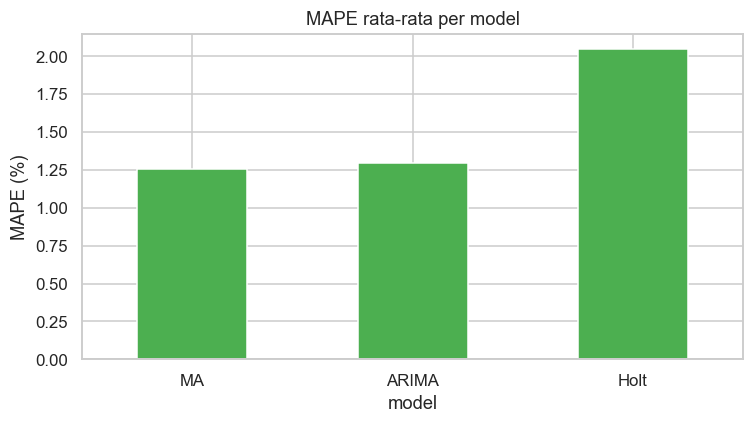

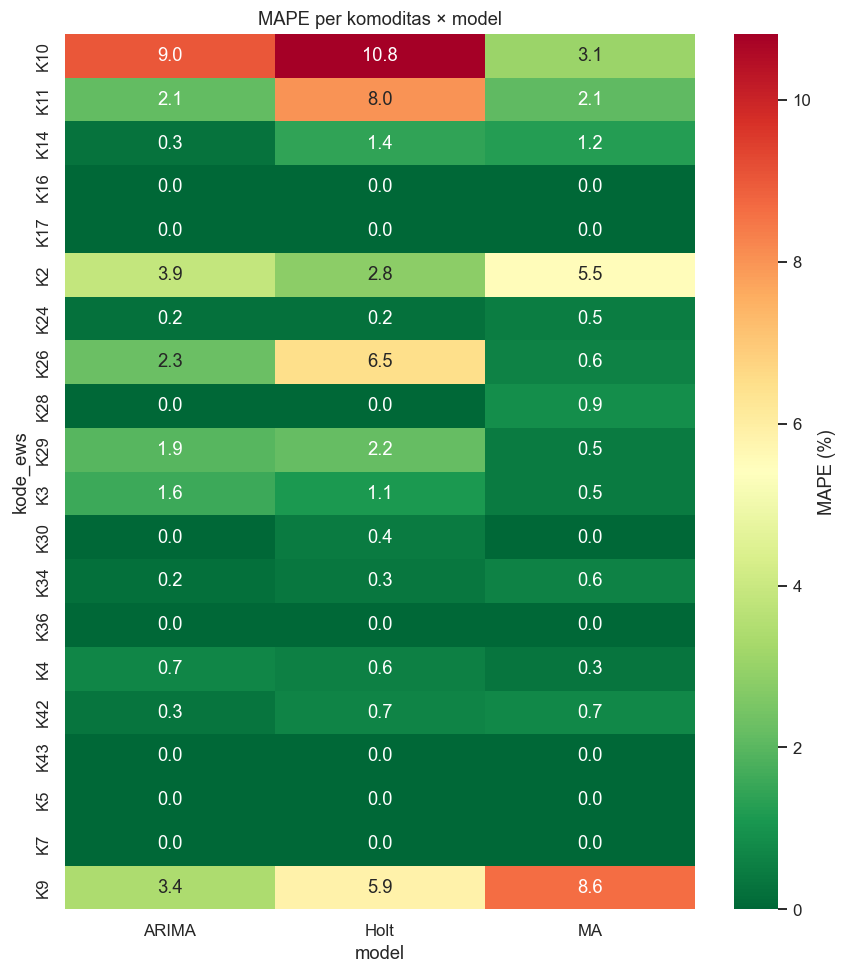

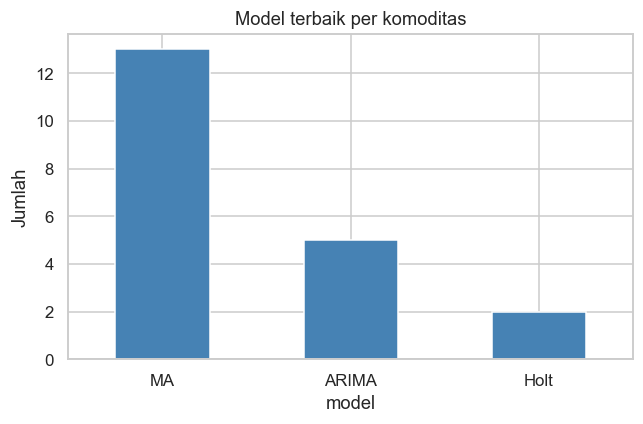

In [11]:
# Bar: MAPE rata-rata per model
plt.figure(figsize=(7, 4))
evaluasi_model.groupby("model")["MAPE"].mean().sort_values().plot(
    kind="bar", color="#4caf50")
plt.title("MAPE rata-rata per model"); plt.ylabel("MAPE (%)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Heatmap: komoditas × model
plt.figure(figsize=(8, 9))
sns.heatmap(evaluasi_model.pivot(index="kode_ews", columns="model", values="MAPE"),
            annot=True, fmt=".1f", cmap="RdYlGn_r", cbar_kws={"label": "MAPE (%)"})
plt.title("MAPE per komoditas × model"); plt.tight_layout(); plt.show()

# Bar: frekuensi model terbaik
plt.figure(figsize=(6, 4))
model_terbaik["model"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Model terbaik per komoditas"); plt.ylabel("Jumlah")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Bab 9c — Visual: forecast H+7 (hasil akhir)
Garis biru = aktual 31 hari · merah putus-putus = ramalan 7 hari.

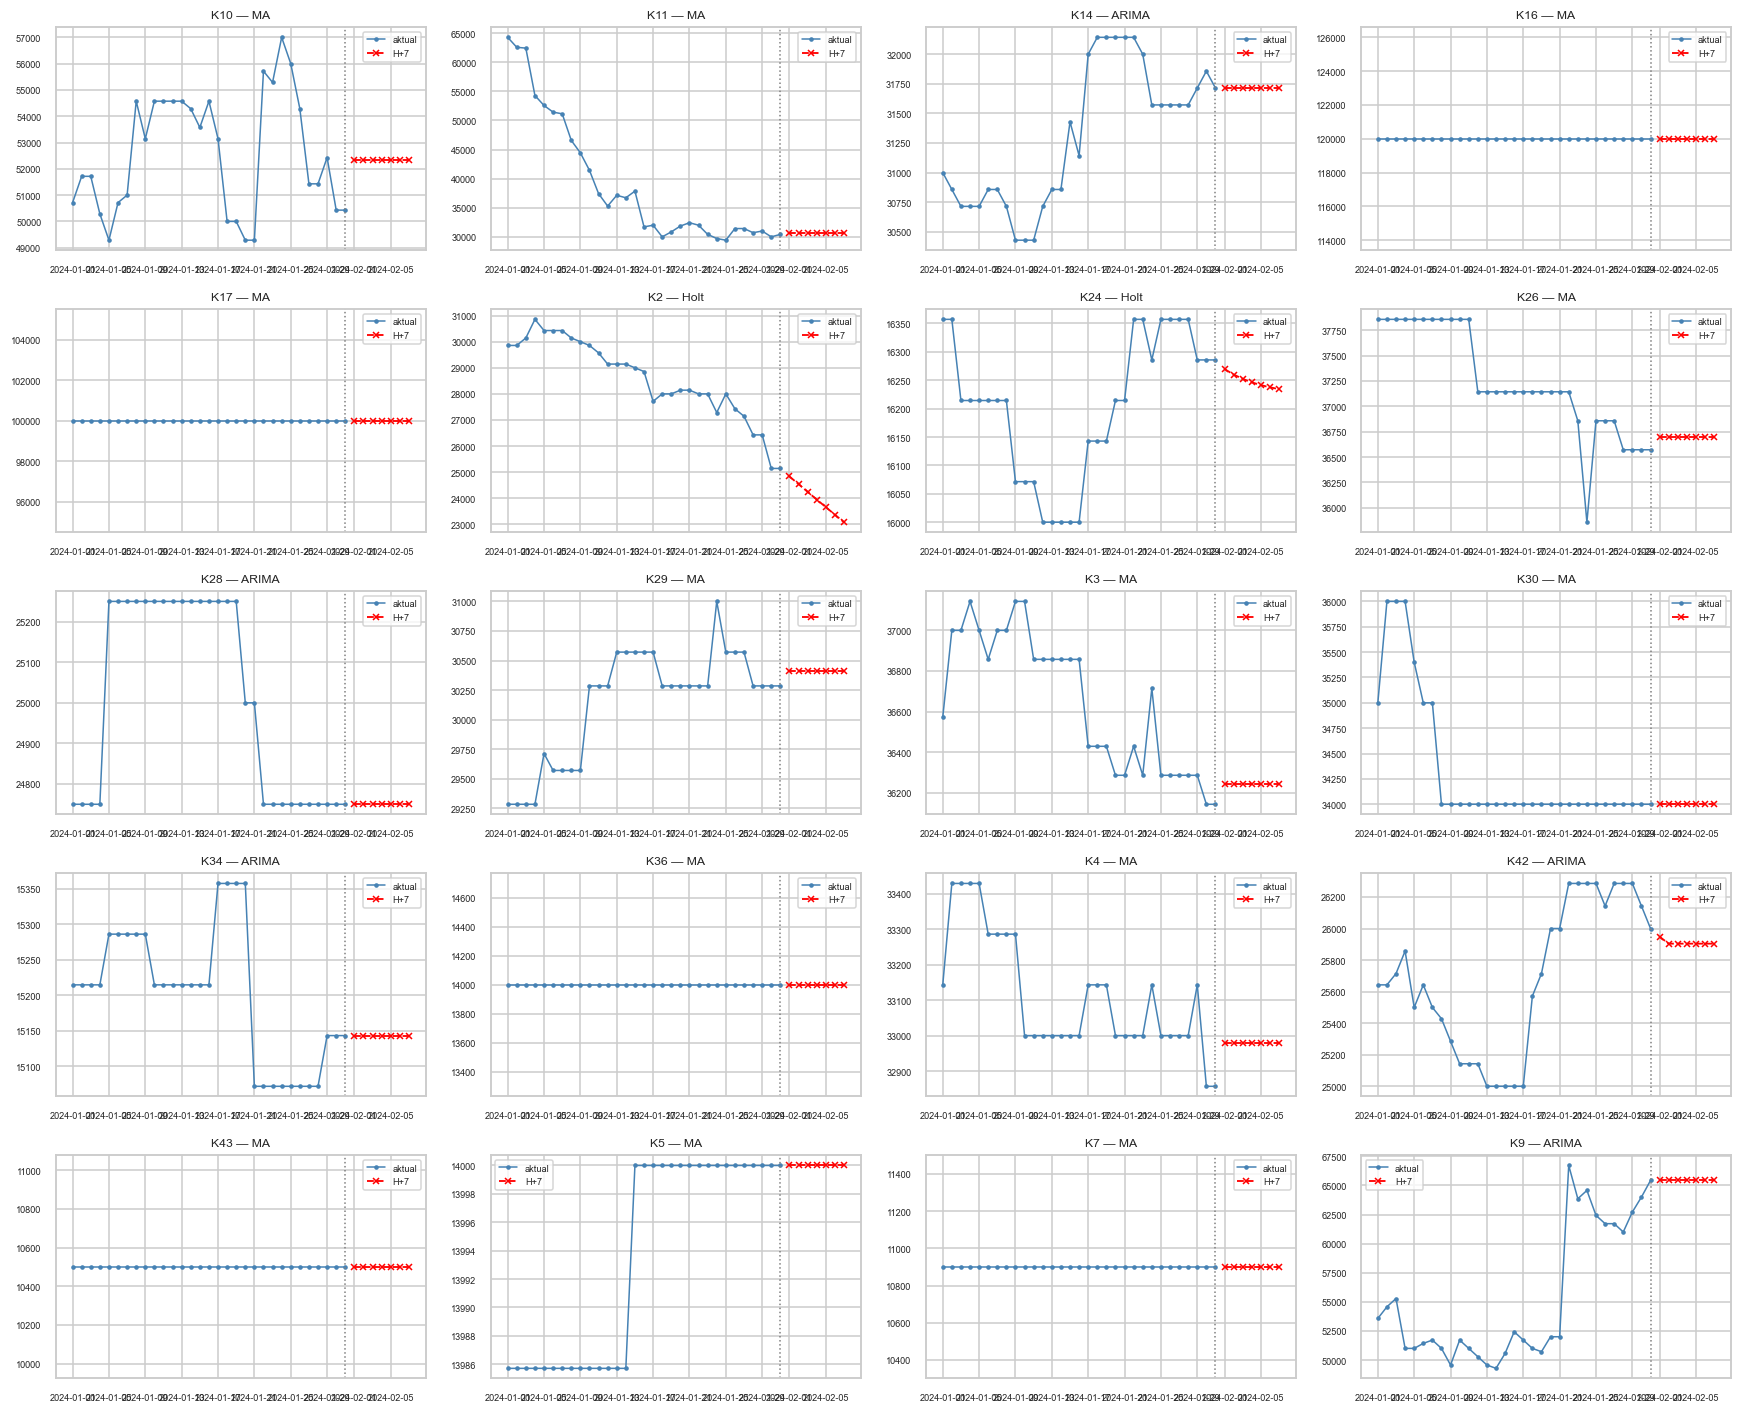

In [12]:
ncol, nrow = 4, (len(dipakai) + 3) // 4
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4, nrow * 2.6))
axes = axes.ravel()
for i, kode in enumerate(sorted(dipakai)):
    ax = axes[i]
    s = seri[kode]
    fc = forecast_h7[forecast_h7["kode_ews"] == kode]
    ax.plot(s.index, s.values, marker="o", ms=2, lw=1, color="steelblue", label="aktual")
    ax.plot(fc["tanggal"], fc["prediksi_harga"], marker="x", ms=4, lw=1.2,
            color="red", ls="--", label="H+7")
    ax.axvline(s.index[-1], color="gray", ls=":", lw=1)
    ax.set_title(f"{kode} — {fc['model'].iloc[0]}", fontsize=8)
    ax.tick_params(labelsize=6); ax.legend(fontsize=6)
for j in range(len(dipakai), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## Bab 10 — Ringkasan Fase 3

In [13]:
print("=== RINGKASAN FASE 3 ===")
print("Komoditas dievaluasi :", len(dipakai), "(K6 & K8 dummy dikecualikan)")
print("Model diuji          : MA, Holt, ARIMA")
print("Split                : 24 train / 7 test")
print("Model terbaik        :", model_terbaik["model"].value_counts().to_dict())
print("MAPE rata-rata       :", round(model_terbaik["MAPE"].mean(), 2), "%")
print("\nCATATAN: K6 & K8 (dummy) tidak dimodelkan.")

=== RINGKASAN FASE 3 ===
Komoditas dievaluasi : 20 (K6 & K8 dummy dikecualikan)
Model diuji          : MA, Holt, ARIMA
Split                : 24 train / 7 test
Model terbaik        : {'MA': 13, 'ARIMA': 5, 'Holt': 2}
MAPE rata-rata       : 0.71 %

CATATAN: K6 & K8 (dummy) tidak dimodelkan.
